In [1]:
import sys
import os
from collections import namedtuple
from pathlib import Path
import json
import datetime
import pprint
from functools import cache

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io
from sklearn.preprocessing import StandardScaler

from tqdm.notebook import tqdm

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

sys.path.append('..')
from lib.utils import *
from lib.logging import *

2025-12-22 22:24:18.085839: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Setup

In [2]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = Path(project_root_path[0])

LOG = Logging()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 'project_root_path, data_path, metrics_path, model_path, notebook_fname, notebook_name, is_cuda, cuda_device')(
    project_root_path=project_root_path,
    data_path=project_root_path / 'data' / 'sparsenet',
    metrics_path=project_root_path / 'tensorboard',
    model_path=Path('.') / 'model',
    notebook_fname='noname.ipynb',
    notebook_name='noname',
    is_cuda=torch.cuda.is_available(),
    cuda_device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)
    CONFIG = CONFIG._replace(notebook_fname=notebook_fname, notebook_name=os.path.splitext(notebook_fname)[0])

pprint.pprint(CONFIG._asdict())

{'cuda_device': device(type='cuda'),
 'data_path': PosixPath('/home/misha/dev/mine/neurovision/data/sparsenet'),
 'is_cuda': True,
 'metrics_path': PosixPath('/home/misha/dev/mine/neurovision/tensorboard'),
 'model_path': PosixPath('model'),
 'notebook_fname': 's2_denoising_ae_02.ipynb',
 'notebook_name': 's2_denoising_ae_02',
 'project_root_path': PosixPath('/home/misha/dev/mine/neurovision')}


# Hypers

In [3]:
HP = namedtuple('HyperParameters', [
    'images_slot',
    'dataset_size',
    'is_dataset_normed',
    'patch_size',
    'noise',
    'filters_count',
    'batch_size',
    'epochs_count',
    'learn_rate', 
], defaults=[None] * 9)(
    images_slot='RAW'
)

# Images

In [4]:
def add_images_to_lib(images, tag):
    IMAGES_LIB[tag] = dict(images=images, image_stds=images.reshape(images.shape[0], -1).std(axis=1))

In [5]:
IMAGES_LIB = {
    'RAW': dict(fname='IMAGES_RAW.mat', mat_name='IMAGESr'),
    'WHITENED': dict(fname='IMAGES.mat', mat_name='IMAGES'),
}

for k in IMAGES_LIB:
    fname = IMAGES_LIB[k]['fname']
    mat_name = IMAGES_LIB[k]['mat_name']
    mat = scipy.io.loadmat(CONFIG.data_path / fname)
    images = mat[mat_name]
    images = np.moveaxis(images, [2], [0])
    add_images_to_lib(images, k)

# Patching

In [6]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, patch_size, image_ind=None, image_stds=None, rng=None):
    blind_area = 4
    trials = 1000
    rng = RNG if rng is None else rng
    image_ind = rng.choice(len(images)) if image_ind is None else image_ind
    image = images[image_ind]

    with_std = not image_stds is None
    
    if with_std:
        image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + rng.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + rng.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

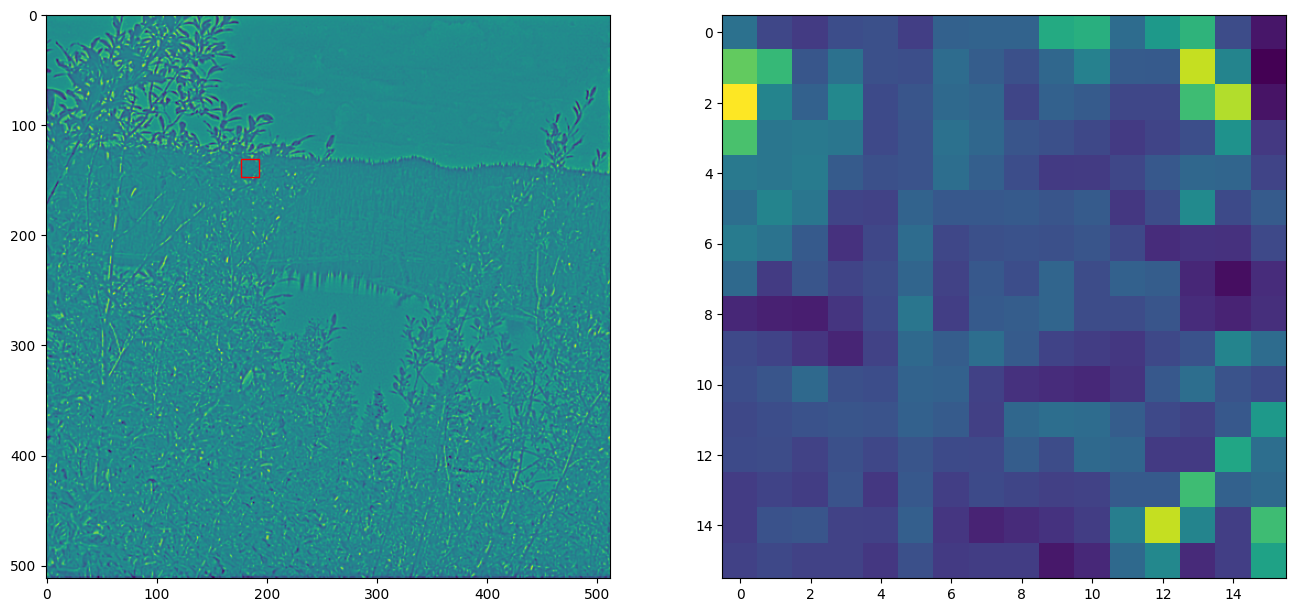

In [7]:
slot = IMAGES_LIB[HP.images_slot]
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.imshow(images[image_ind]);
rect = pltpatches.Rectangle((j_off, i_off), patch.shape[1], patch.shape[0], linewidth=1, edgecolor='r', facecolor='none')
ax1.add_patch(rect)
ax2.imshow(patch);

# Noising

## gauss_noise

In [8]:
def gauss_noise(patches, gadds_tab):
    if patches.ndim == 2:
        assert patches.shape[1] == gadds_tab.shape[1], f'Shape mismatch: {patches.shape[1]} vs {gadds_tab.shape[1]}'
        patches_count = len(patches)
        noise = gadds_tab[RNG.choice(len(gadds_tab), patches_count)]
    elif patches.ndim == 1:
        gadd_ind = RNG.choice(len(gadds_tab))
        noise = gadds_tab[gadd_ind]
    else:
        assert False, f'Unsupported dimensions count for patches: {patches.ndim}'

    if isinstance(patches, np.ndarray):
        return patches + noise
    elif isinstance(patches, torch.Tensor):
        return patches + torch.tensor(noise, device=patches.device, dtype=patches.dtype)

## masking_noise

In [9]:
def masking_noise(patches, masks_tab, fill_value=0):
    if patches.ndim == 2:
        assert patches.shape[1] == masks_tab.shape[1], f'Shape mismatch: {patches.shape[1]} vs {masks_tab.shape[1]}'
        patches_count = len(patches)
        mask_inds = RNG.choice(len(masks_tab), patches_count, replace=False)
        boolmap = masks_tab[mask_inds]
    elif patches.ndim == 1:
        mask_ind = RNG.choice(len(masks_tab))
        boolmap = masks_tab[mask_ind]
    else:
        assert False, f'Unsupported dimensions count for patches: {patches.ndim}'

    if isinstance(patches, np.ndarray):
        noised = patches.copy()
    elif isinstance(patches, torch.Tensor):
        noised = patches.clone()
    else:
        assert False, f'Unsupported type(patches): {type(patches)}'

    noised[boolmap] = fill_value
    return noised

## generate_zmasks

In [10]:
def generate_zmasks(patch_size, ν, count):
    patch_flat_size = patch_size ** 2
    zero_inds_count = int(ν * patch_flat_size)
    zmasks = np.full((count, patch_flat_size), False)
    
    for i in range(count):
        zero_inds = RNG.choice(patch_flat_size, zero_inds_count, replace=False)
        zmasks[i,zero_inds] = True

    return zmasks    

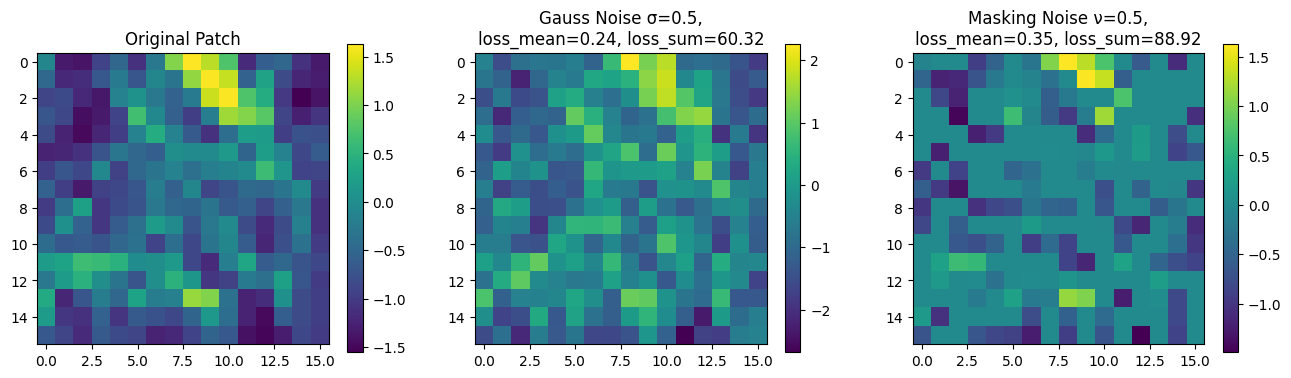

In [11]:
slot = IMAGES_LIB[HP.images_slot]
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original Patch')
im = ax1.imshow(patch);
fig.colorbar(im, ax=ax1, shrink=.5)

σ = 0.5
gadds = RNG.normal(0, σ, (100, patch.shape[0]**2))
noised = gauss_noise(patch.ravel(), gadds)
noised = noised.reshape(patch.shape)
ax2.set_title(f'Gauss Noise σ={σ},\nloss_mean={((patch - noised)**2).mean():.2f}, loss_sum={((patch - noised)**2).sum():.2f}')
im = ax2.imshow(noised);
fig.colorbar(im, ax=ax2, shrink=.5)

ν = 0.5
zmasks = generate_zmasks(patch.shape[1], ν, 100)
noised = masking_noise(patch.ravel(), zmasks, fill_value=0)
noised = noised.reshape(patch.shape)
ax3.set_title(f'Masking Noise ν={ν},\nloss_mean={((patch - noised)**2).mean():.2f}, loss_sum={((patch - noised)**2).sum():.2f}')
im = ax3.imshow(noised);
fig.colorbar(im, ax=ax3, shrink=.5);

# Dataset

In [12]:
dataset_rng = np.random.default_rng(82)
HP = HP._replace(
    dataset_size=1_000_000,
    # is_dataset_normed=True,
    is_dataset_normed=False,
    patch_size=12,
)

In [13]:
images = IMAGES_LIB[HP.images_slot]['images']
DATASET = []

for i in tqdm(range(HP.dataset_size)):
    patch = extract_image_patch(images, HP.patch_size, rng=dataset_rng).patch
    DATASET.append(patch.ravel())

DATASET = np.array(DATASET)

if HP.is_dataset_normed:
    DATASET_SCALER = StandardScaler()
    DATASET = DATASET_SCALER.fit_transform(DATASET)
    
DATASET = torch.Tensor(DATASET)

  0%|          | 0/1000000 [00:00<?, ?it/s]

# Model

In [14]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, hiddens_count, noise_func):
        super().__init__()
        self.filters = tnn.Linear(inp_dims_count, hiddens_count)
        self.decoder = tnn.Linear(hiddens_count, inp_dims_count)
        self.noise_func = noise_func

        bound = 1 / np.sqrt(inp_dims_count)
        self.filters.weight.data.uniform_(-bound, bound)
        bound = 1 / np.sqrt(hiddens_count)
        self.decoder.weight.data.uniform_(-bound, bound)

    def forward(self, inp):
        noised = self.noise_func(inp)
        out = tnnf.sigmoid(self.filters(noised))
        out = self.decoder(out)
        
        if self.training:
            return out
        else:
            return out, noised

In [15]:
model = DenoiseAutoencoder(144, 200, lambda p: gauss_noise(p, RNG.normal(0, 0.5, (100, 144))))
sum([p.numel() for p in model.parameters()])

57944

In [16]:
data_loader = DataLoader(DATASET, batch_size=100)
model(next(iter(data_loader))).shape

torch.Size([100, 144])

# Training

We trained both regular autoencoders and denoising autoencoders on 12×12 patches from whitened natural scene images, made available by Olshausen (Olshausen and Field, 1996)... 

For these natural image patches, we used a linear decoder and a squared reconstruction cost. Network parameters were trained from a random start, using stochastic gradient descent to perform 500000 weight updates with a fixed learning rate of 0.05. All filters shown were from experiments with tied weights, but untied weights yielded similar results.

We then trained 200 hidden units over-complete noiseless autoencoders regularized with L2 weight decay, as well as 200 hidden units denoising autoencoders with isotropic Gaussian noise (but no weight decay). ... With a sufficiently large noise level however (σ = 0.5), the denoising autoencoder learns Gabor-like local oriented edge detectors 

In [17]:
@cache
def gadds_50():
    return RNG.normal(0, 0.5, (HP.dataset_size, HP.patch_size**2)).astype(float)

@cache
def zmasks_10():
    return generate_zmasks(HP.patch_size, 0.10, HP.dataset_size)

@cache
def zmasks_25():
    return generate_zmasks(HP.patch_size, 0.25, HP.dataset_size)

In [20]:
noise_funcs = {
    'Gauss_0.5': lambda p: gauss_noise(p, gadds_50()),
    'Masking_0.1': lambda p: masking_noise(p, zmasks_10()),
    'Masking_0.25': lambda p: masking_noise(p, zmasks_25()),
    'Masking_0.25_1': lambda p: masking_noise(p, zmasks_25(), fill_value=1),
}
HP = HP._replace(
    filters_count=200,
    batch_size=10_000,
    epochs_count=100,
    learn_rate=0.05,
    noise='Gauss_0.5',
    # noise='Masking_0.25',
    # noise='Masking_0.25_1',
)
pprint.pprint(HP._asdict())

{'batch_size': 10000,
 'dataset_size': 1000000,
 'epochs_count': 100,
 'filters_count': 200,
 'images_slot': 'RAW',
 'is_dataset_normed': False,
 'learn_rate': 0.05,
 'noise': 'Gauss_0.5',
 'patch_size': 12}


In [21]:
data_loader = DataLoader(DATASET, batch_size=HP.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
model = DenoiseAutoencoder(HP.patch_size**2, HP.filters_count, noise_funcs[HP.noise]).to(device=CONFIG.cuda_device)
optimizer = topt.Adam(model.parameters(), lr=HP.learn_rate)
loss_fn = tnn.MSELoss()
epoch = 0

metrics_dir = CONFIG.metrics_path / CONFIG.notebook_name / datetime.datetime.now().strftime('%y-%m-%dT%H:%M:%S')
metrics_writer = SummaryWriter(log_dir=metrics_dir)

In [22]:
model.train()

for _ in tqdm(range(HP.epochs_count)):
    epoch += 1
    loss_train = 0
    
    for batch in data_loader:
        optimizer.zero_grad()
        
        true_data = batch.to(device=CONFIG.cuda_device)
        infer_data = model(true_data)
        loss = loss_fn(infer_data, true_data)
        loss.backward()
        
        optimizer.step()
        
        loss_train += loss.item()
    
    metrics_writer.add_scalar('loss', loss_train / len(data_loader), epoch)
    metrics_writer.flush()

  0%|          | 0/100 [00:00<?, ?it/s]

In [23]:
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hypers': HP._asdict(),
}, CONFIG.model_path / f'{CONFIG.notebook_name}_{datetime.datetime.now().strftime('%y-%m-%dT%H:%M:%S')}.pt')

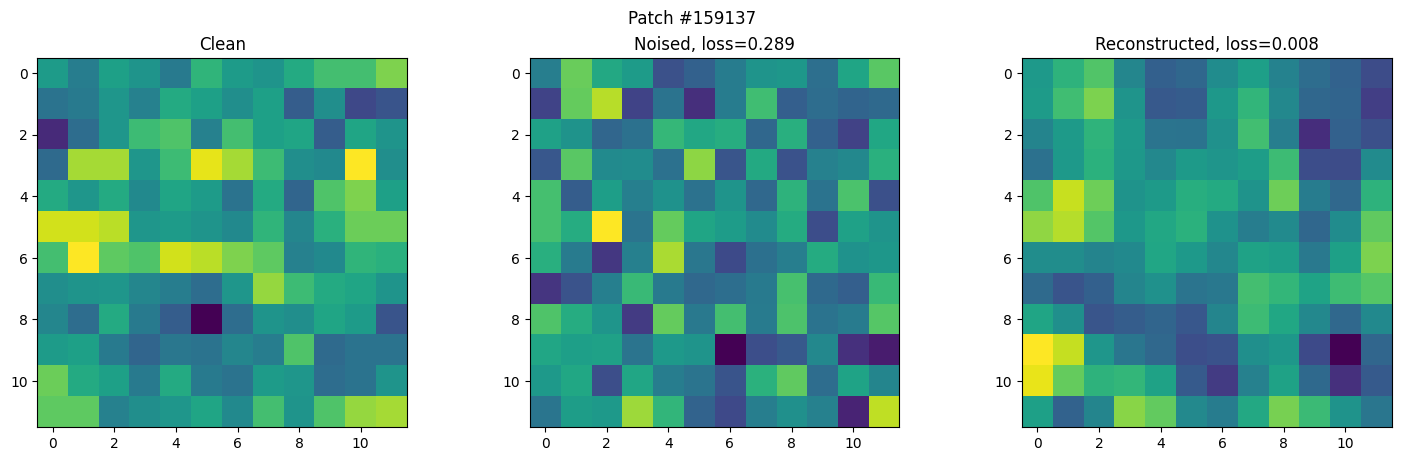

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

ind = RNG.choice(len(DATASET))
clean = DATASET[ind]

model.eval()

with torch.no_grad():
    reconstructed, noised = model(clean.reshape(1, -1).to(CONFIG.cuda_device))
    reconstructed = reconstructed.to(device='cpu').detach().ravel()
    noised = noised.to(device='cpu').detach().ravel()

ax1.set_title('Clean')
ax1.imshow(vec_to_square_matrix(clean))

ax2.set_title(f'Noised, loss={loss_fn(noised, clean):.3f}')
ax2.imshow(vec_to_square_matrix(noised))

ax3.set_title(f'Reconstructed, loss={loss_fn(reconstructed, clean):.3f}')
ax3.imshow(vec_to_square_matrix(reconstructed));

plt.suptitle(f'Patch #{ind}');

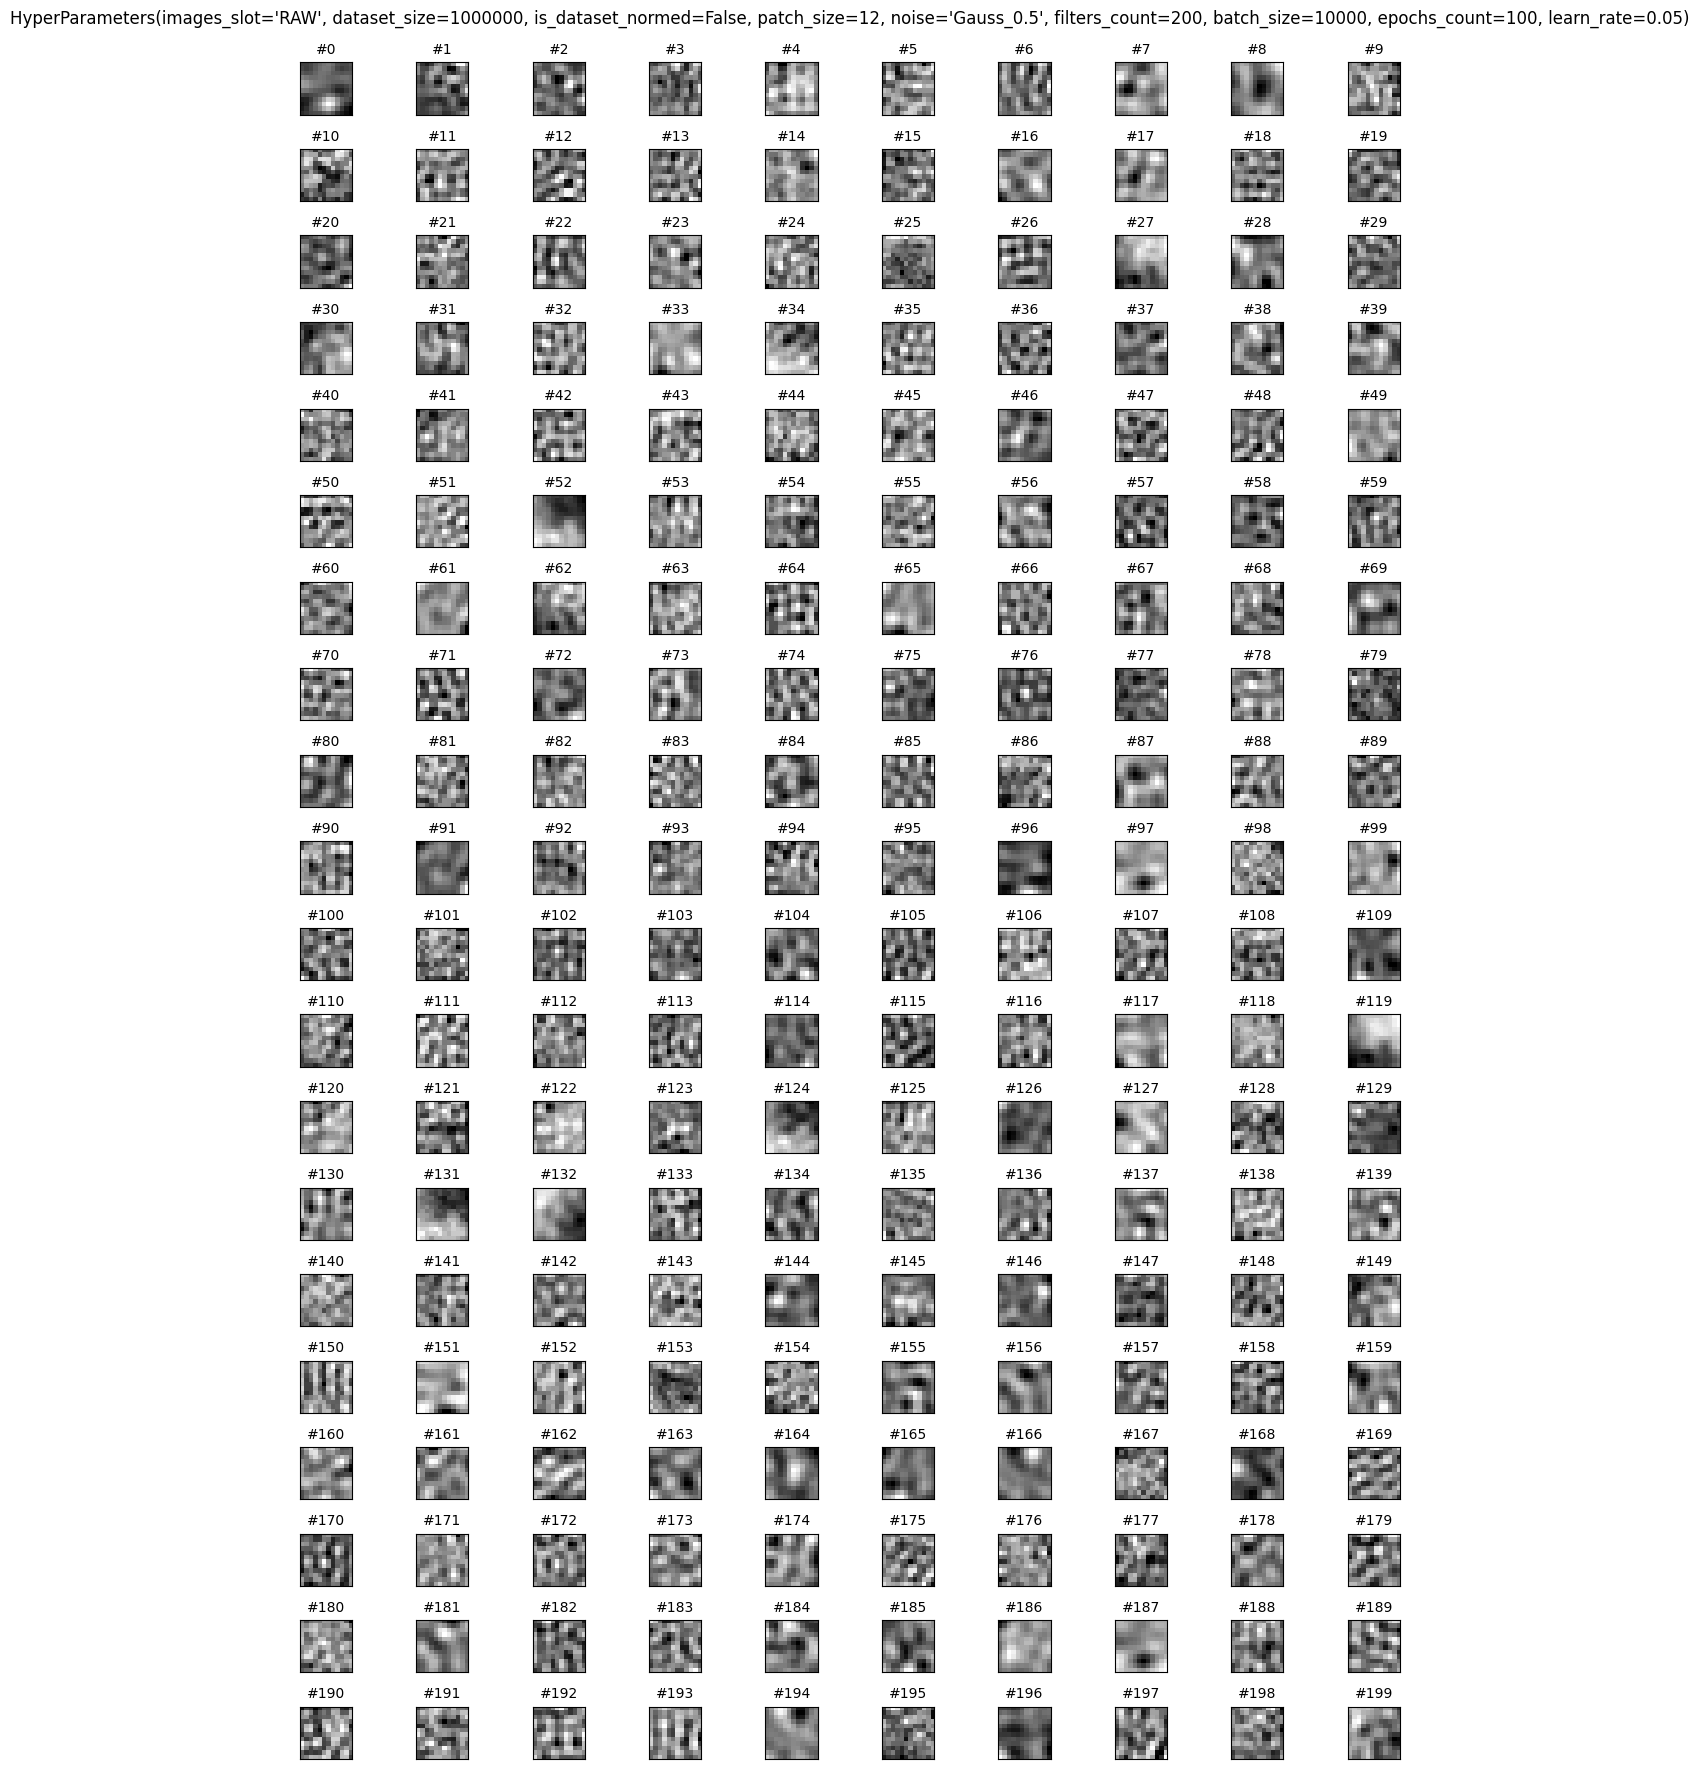

In [28]:
bases_in_row = 10
fig, axes = plt.subplots(int(np.ceil(HP.filters_count / bases_in_row)), bases_in_row)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = model.filters.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(vec_to_square_matrix(f), cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(pprint.pformat(HP) + '\n')
plt.tight_layout()

# Results

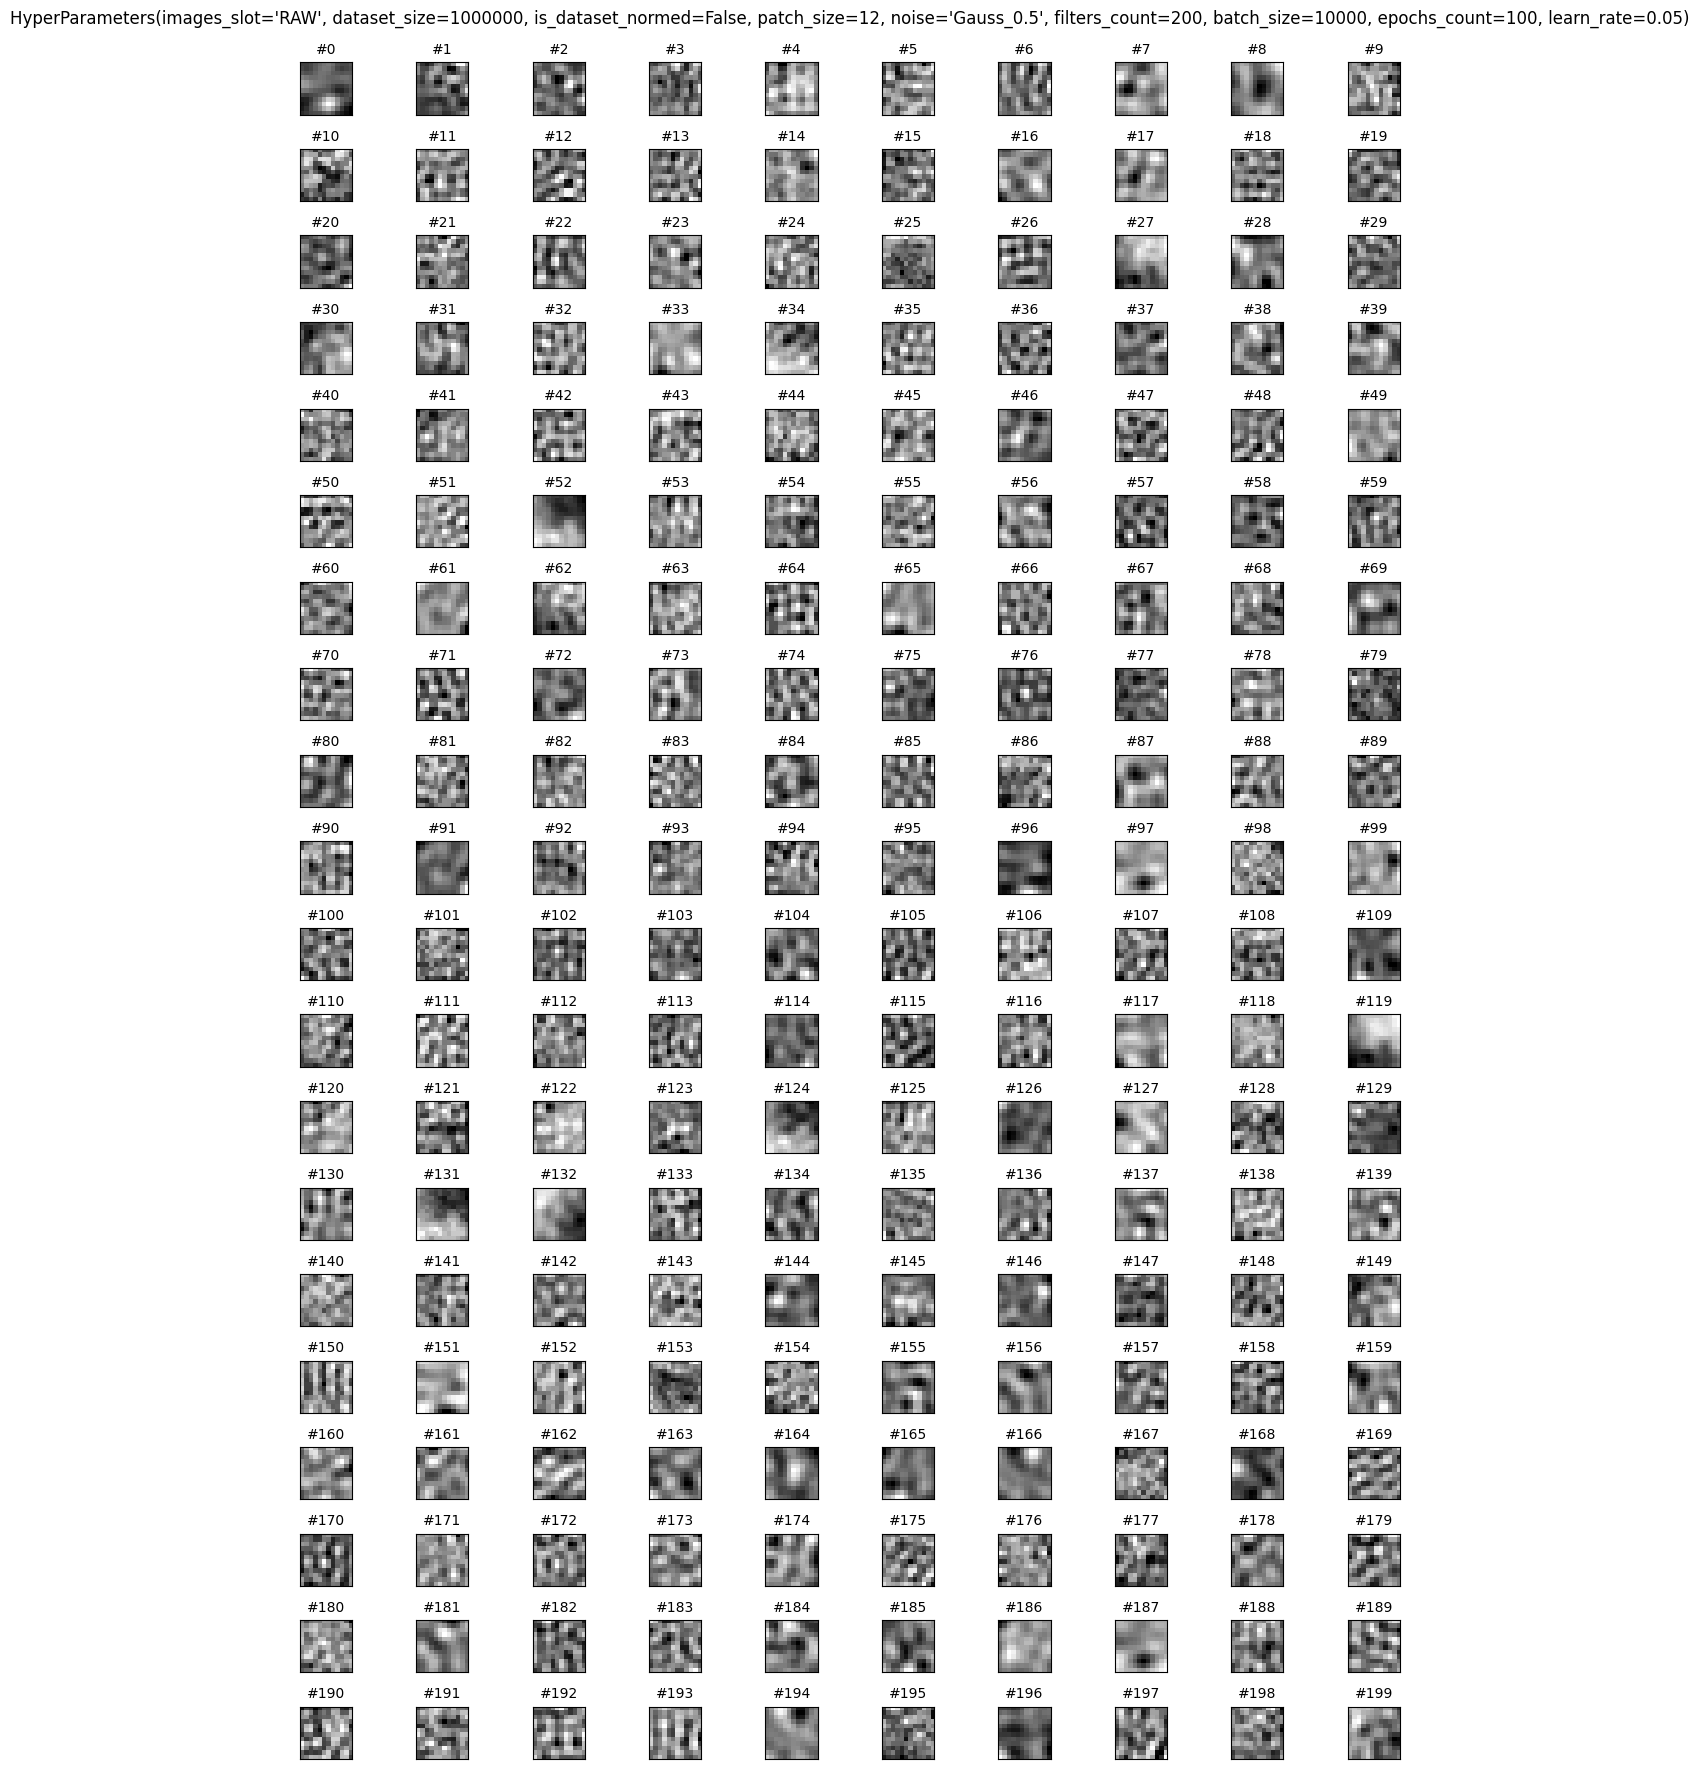

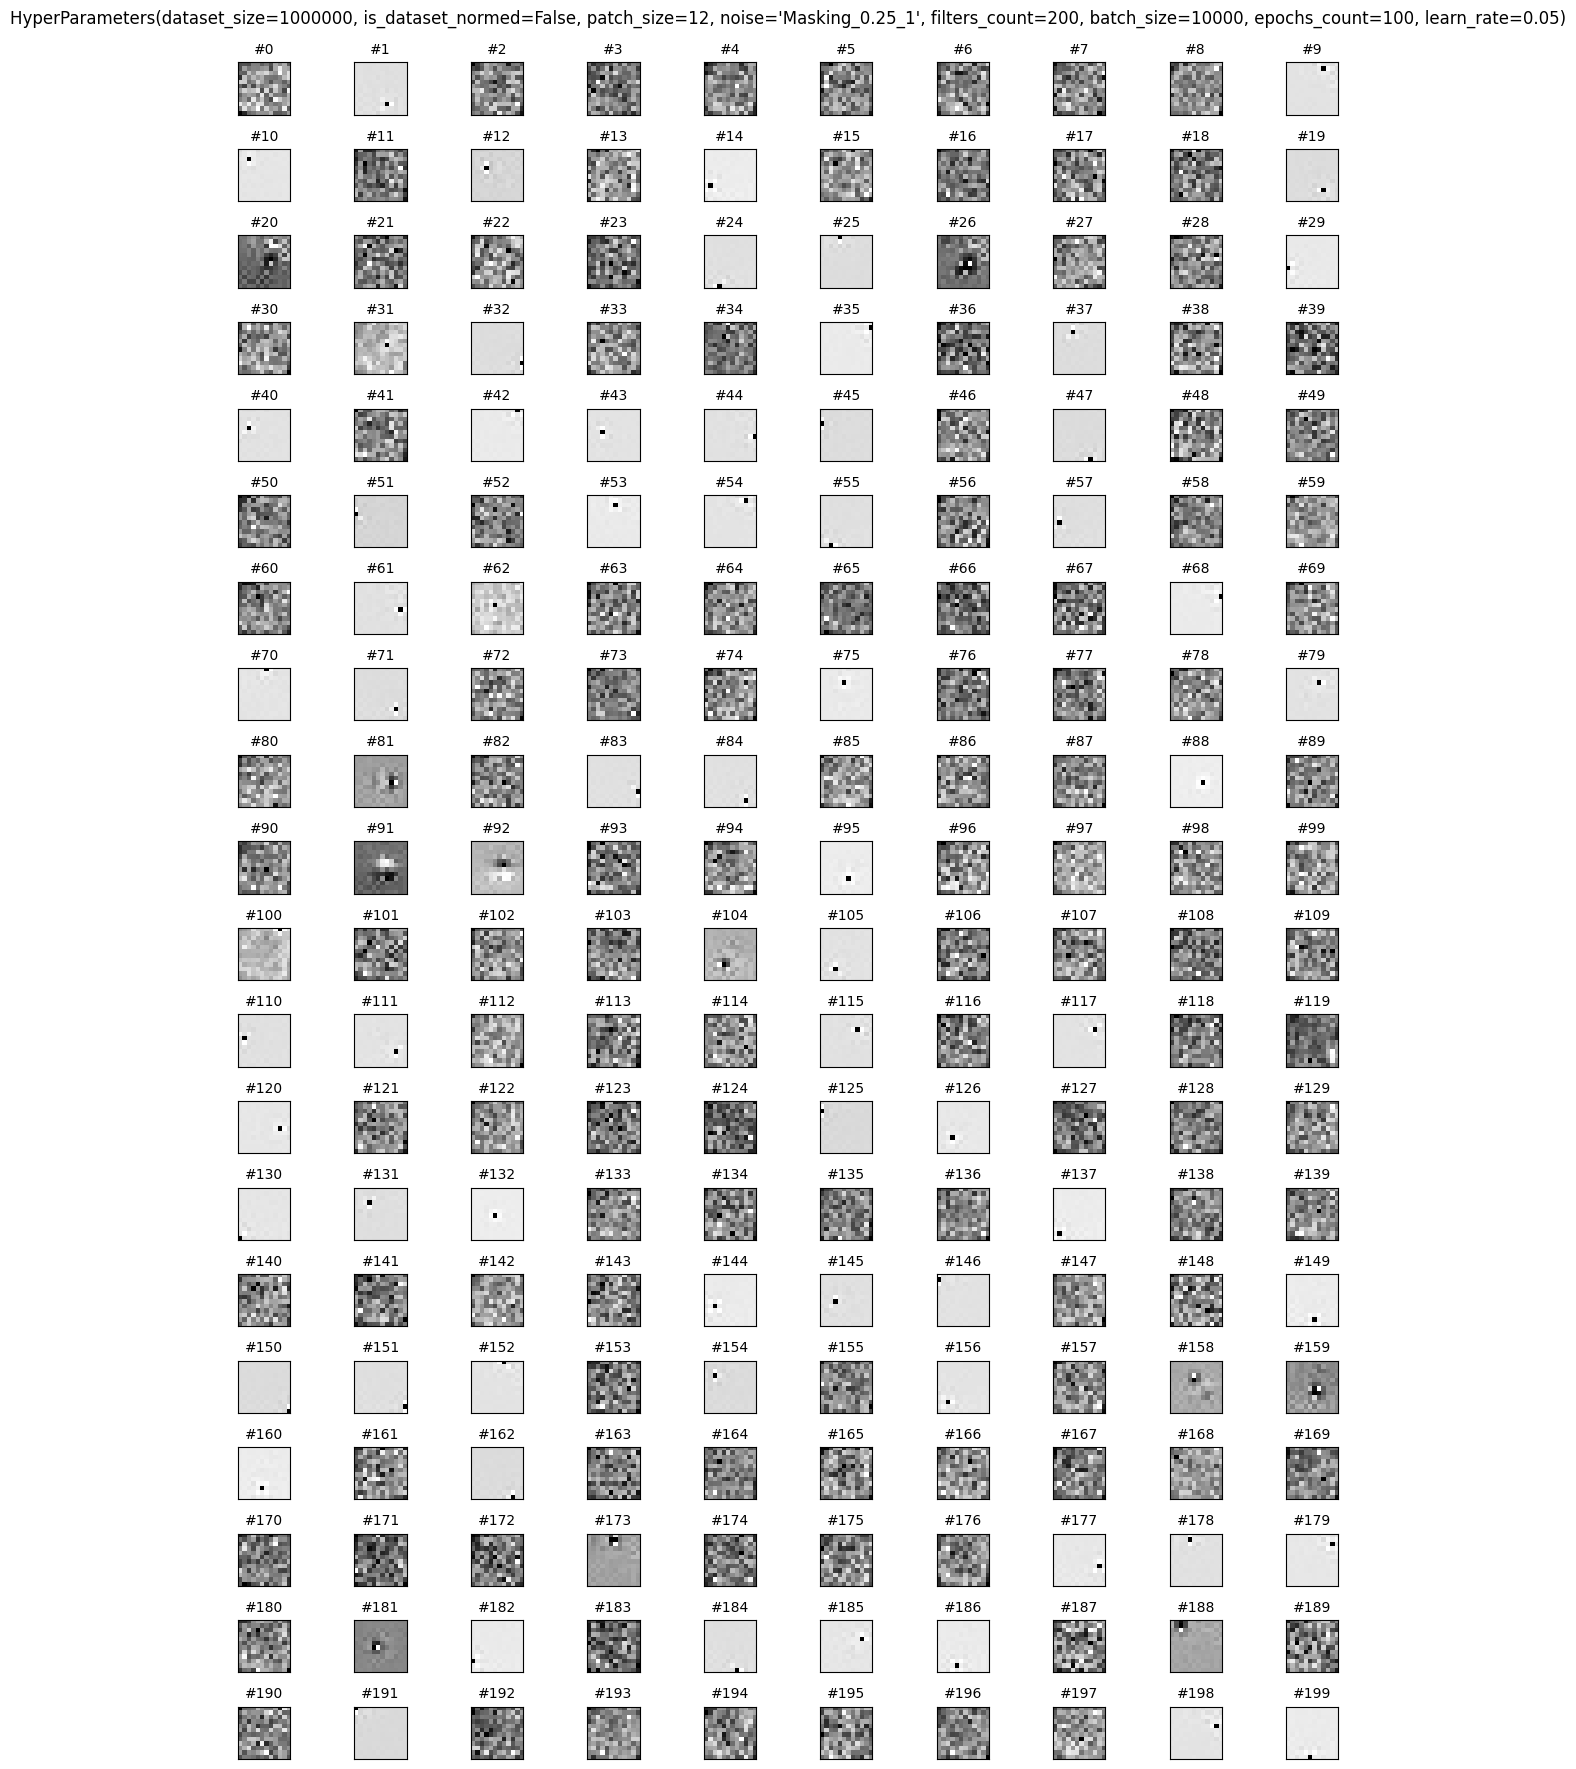

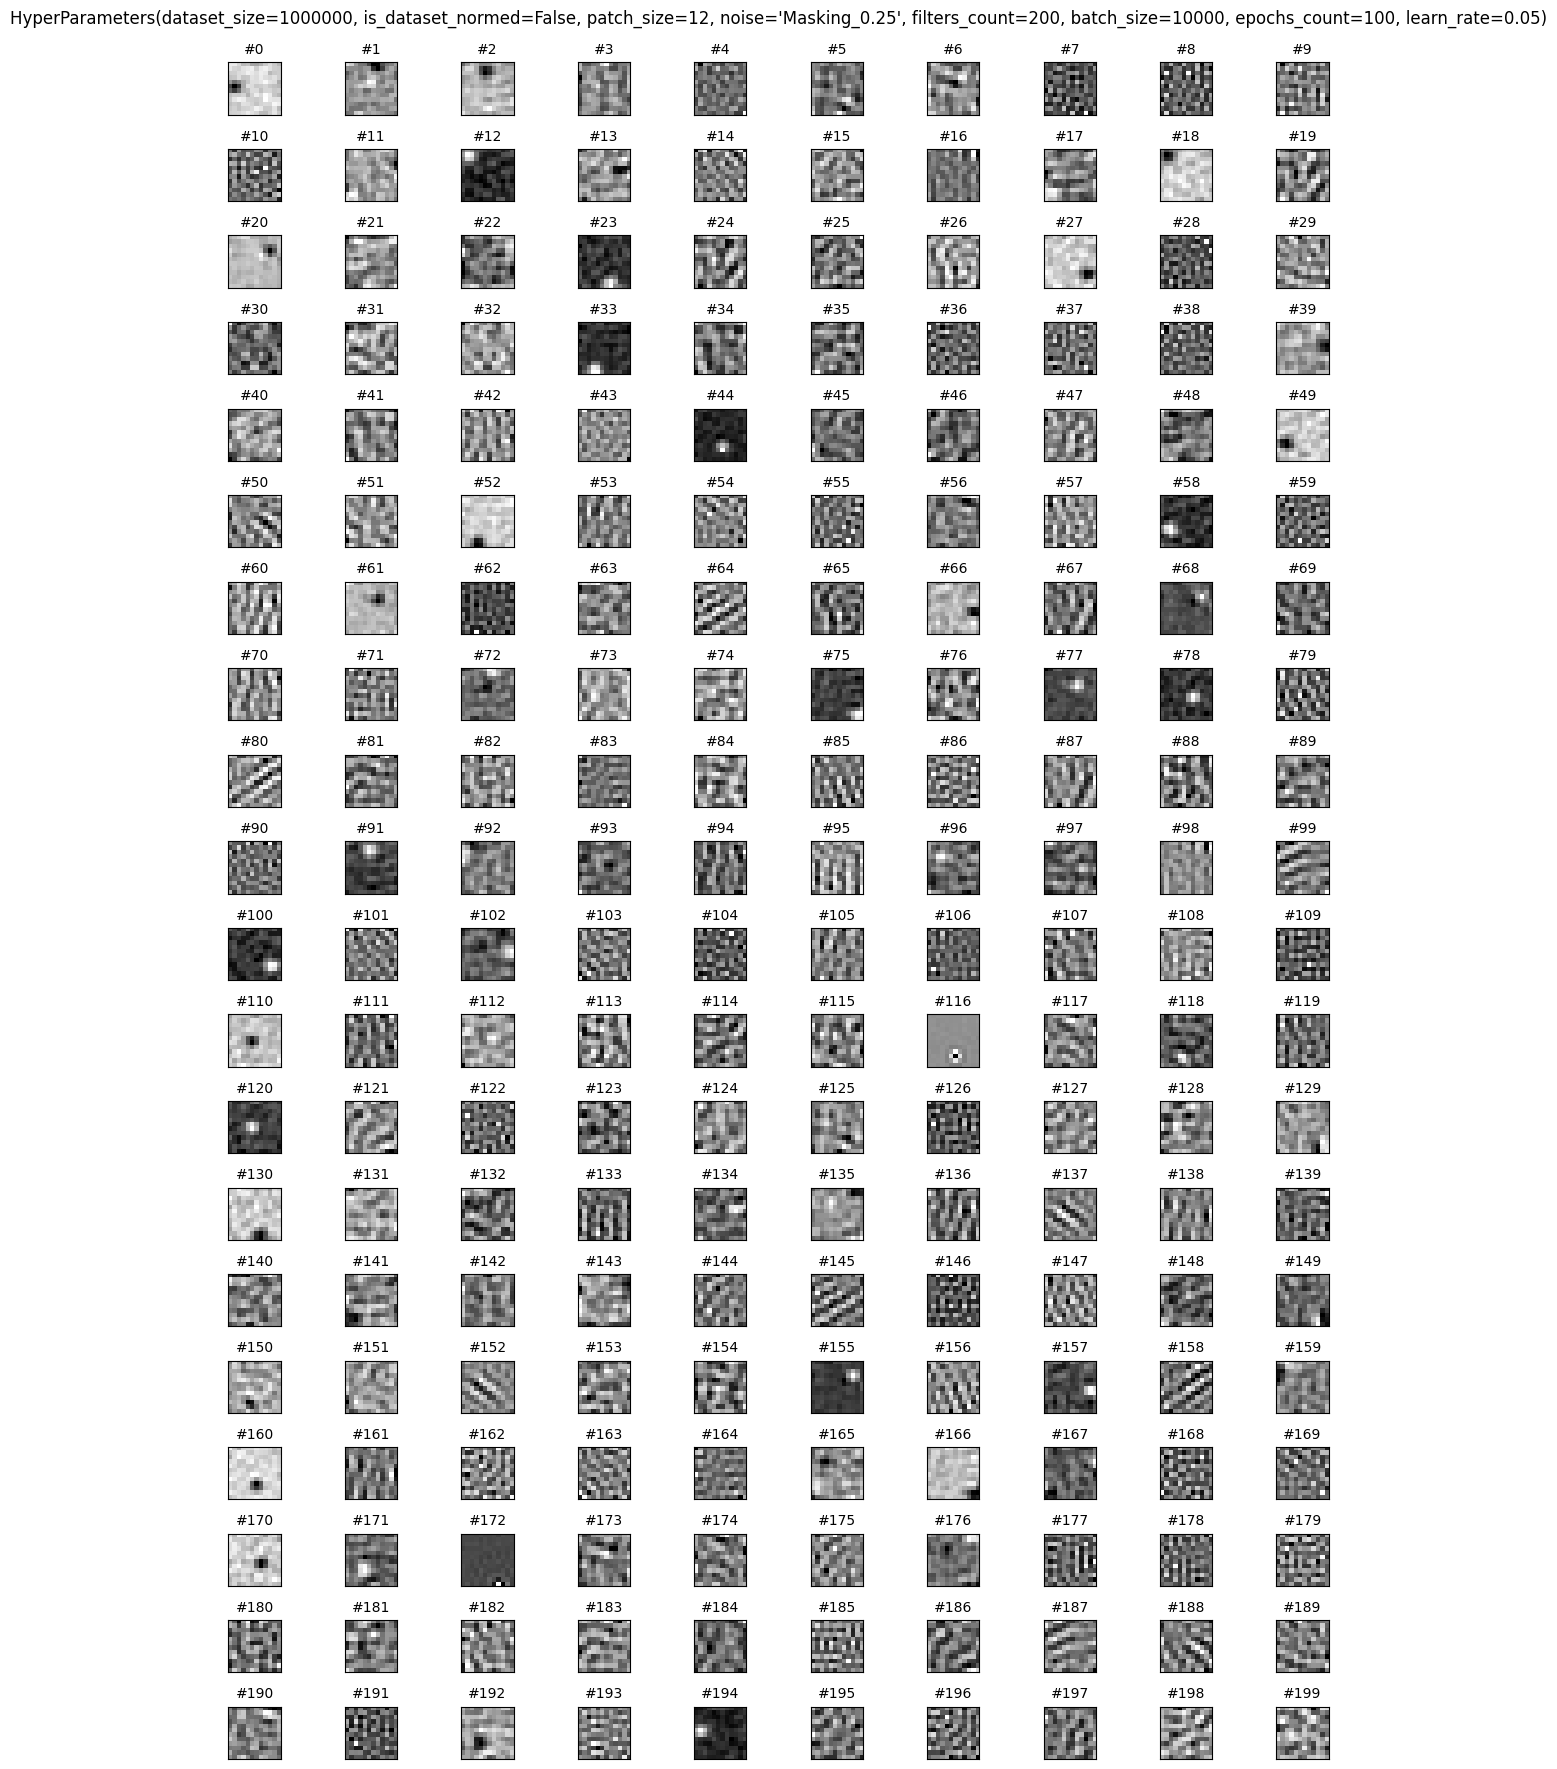

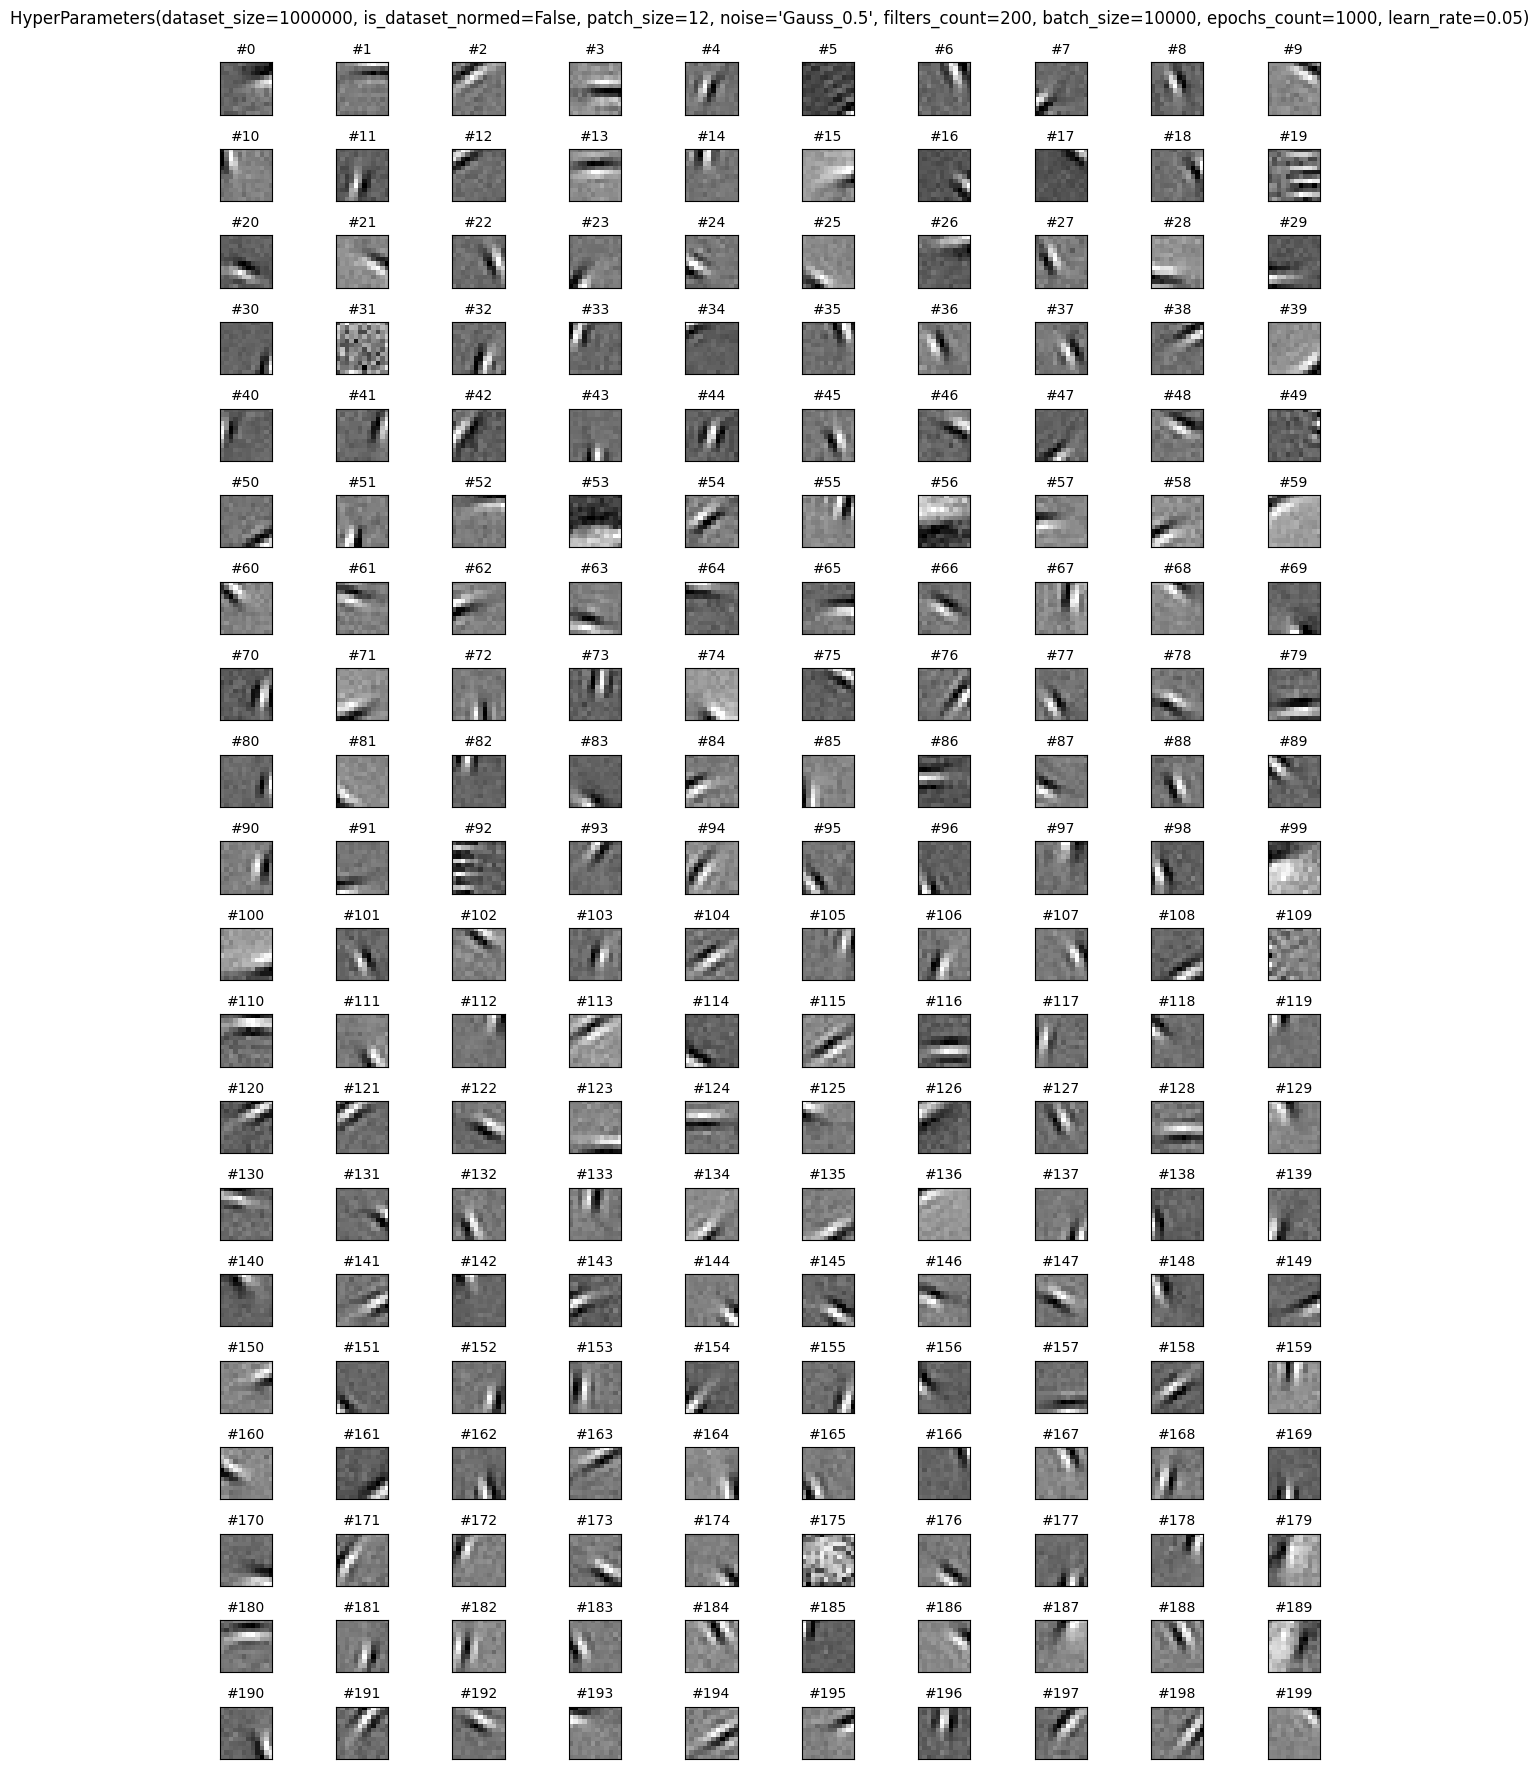

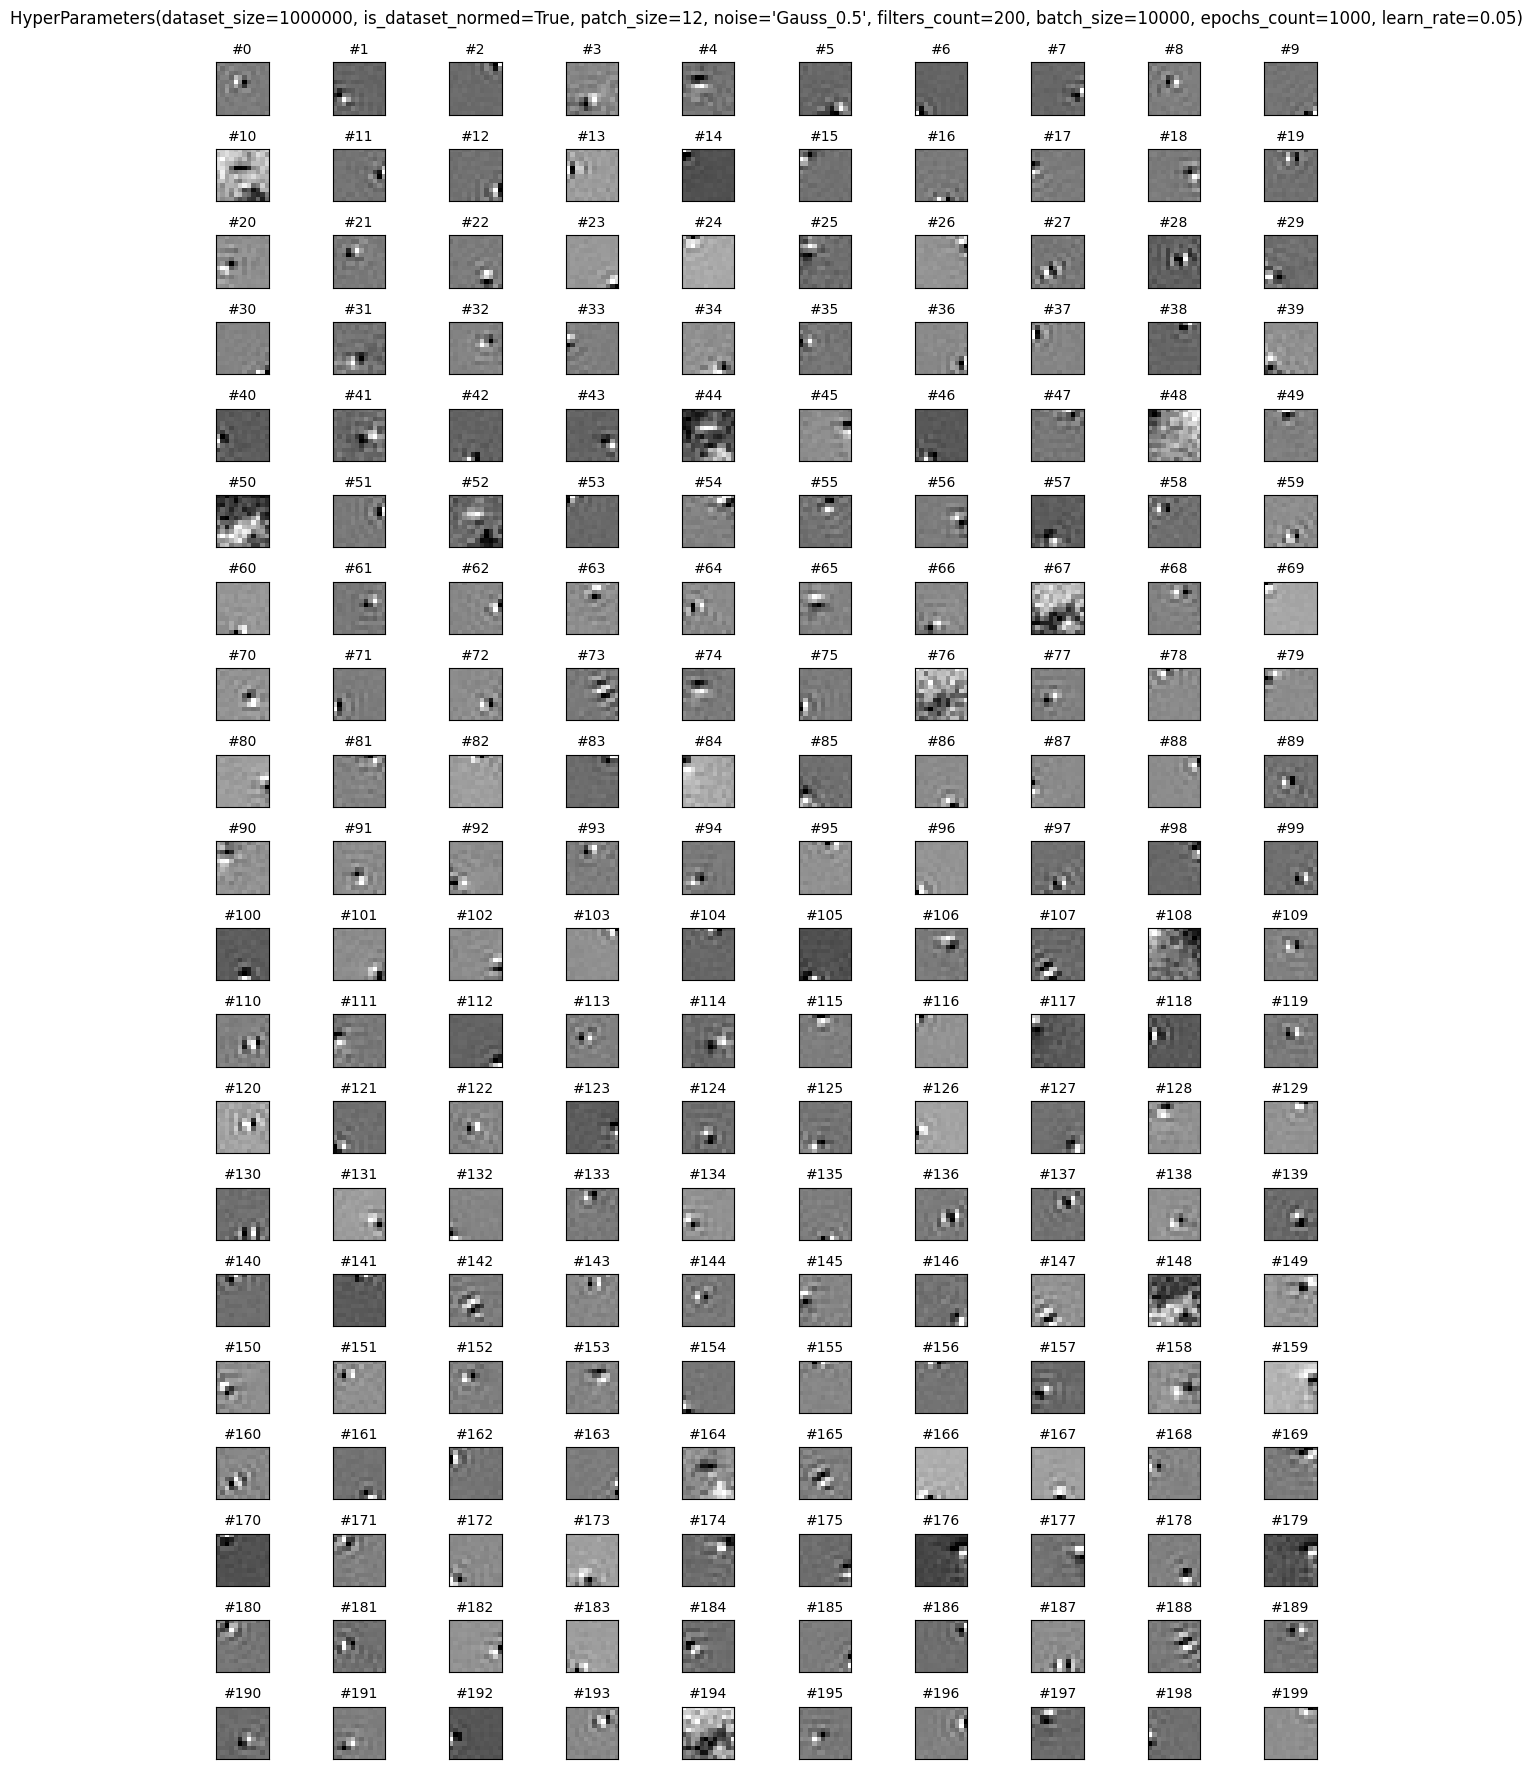

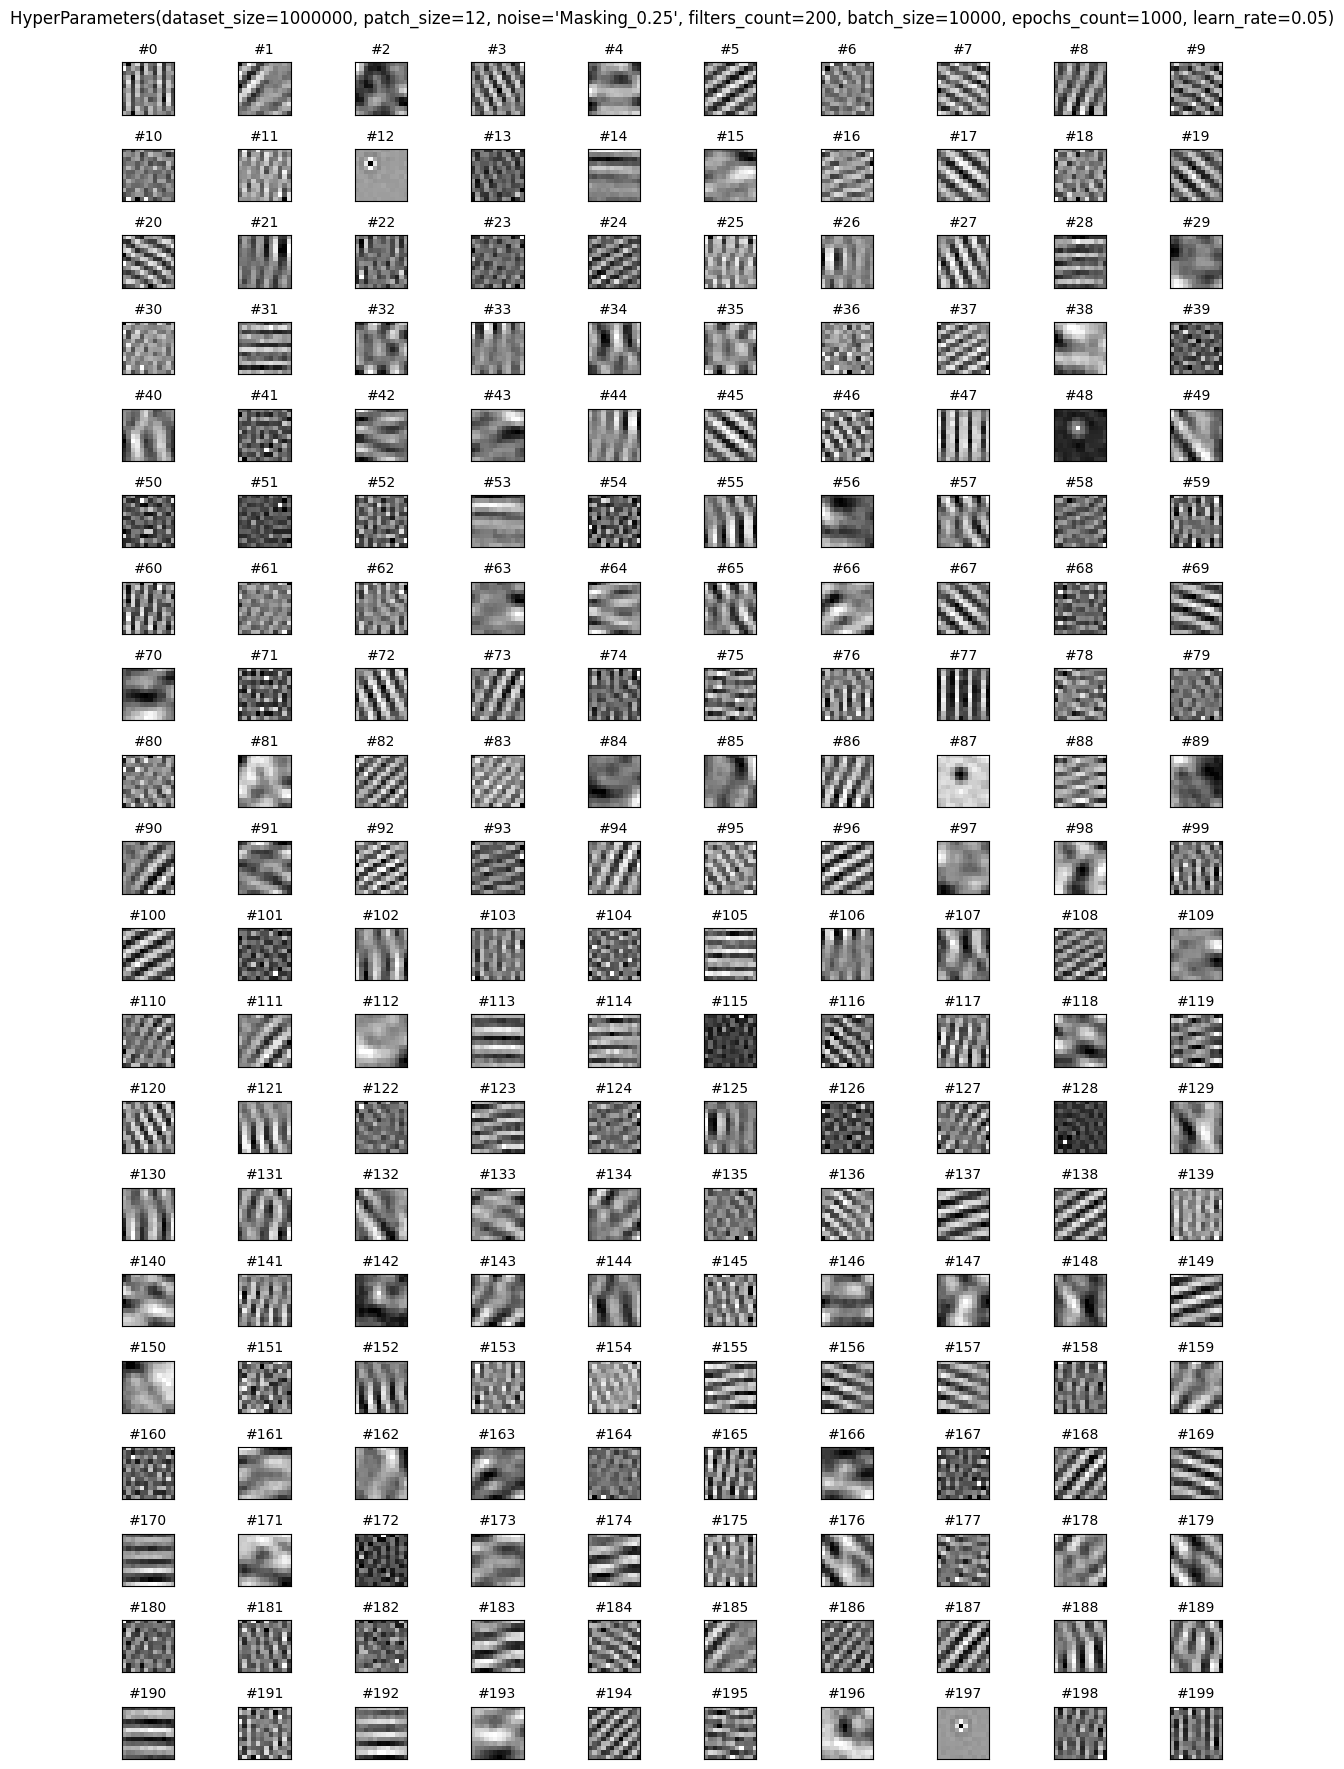

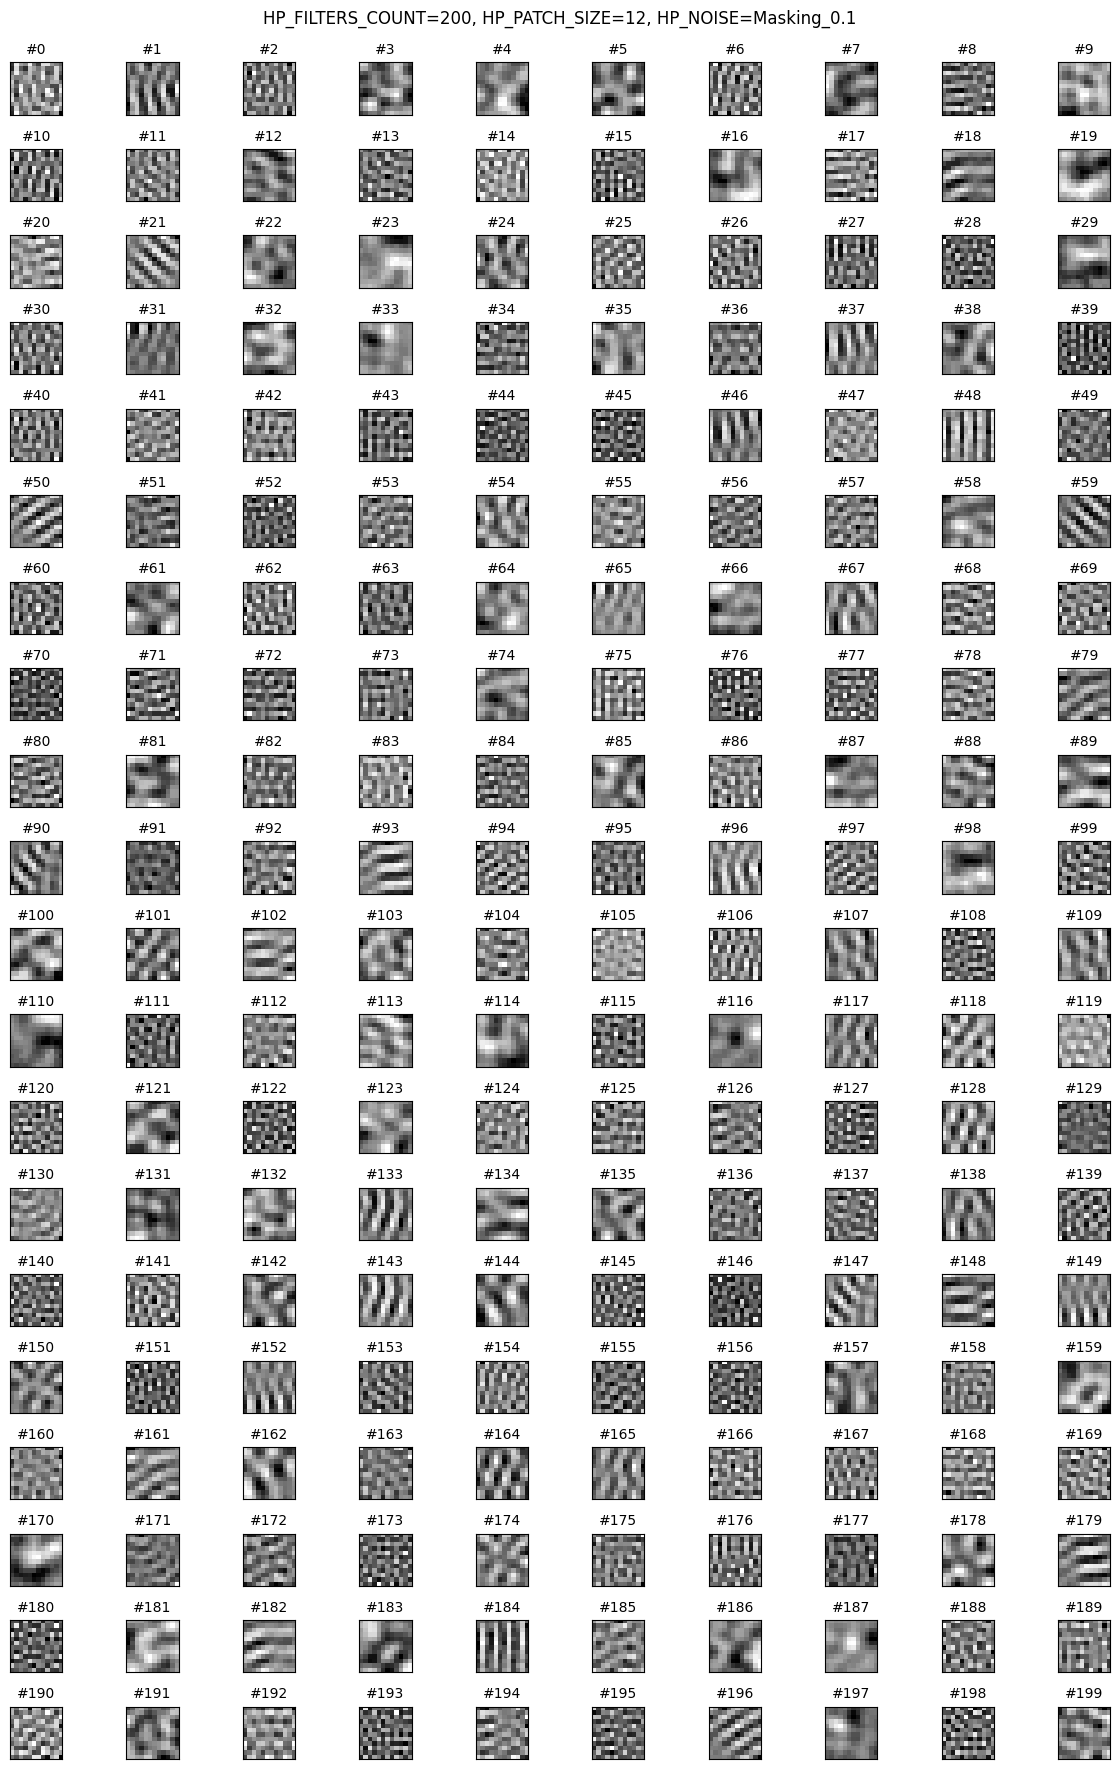

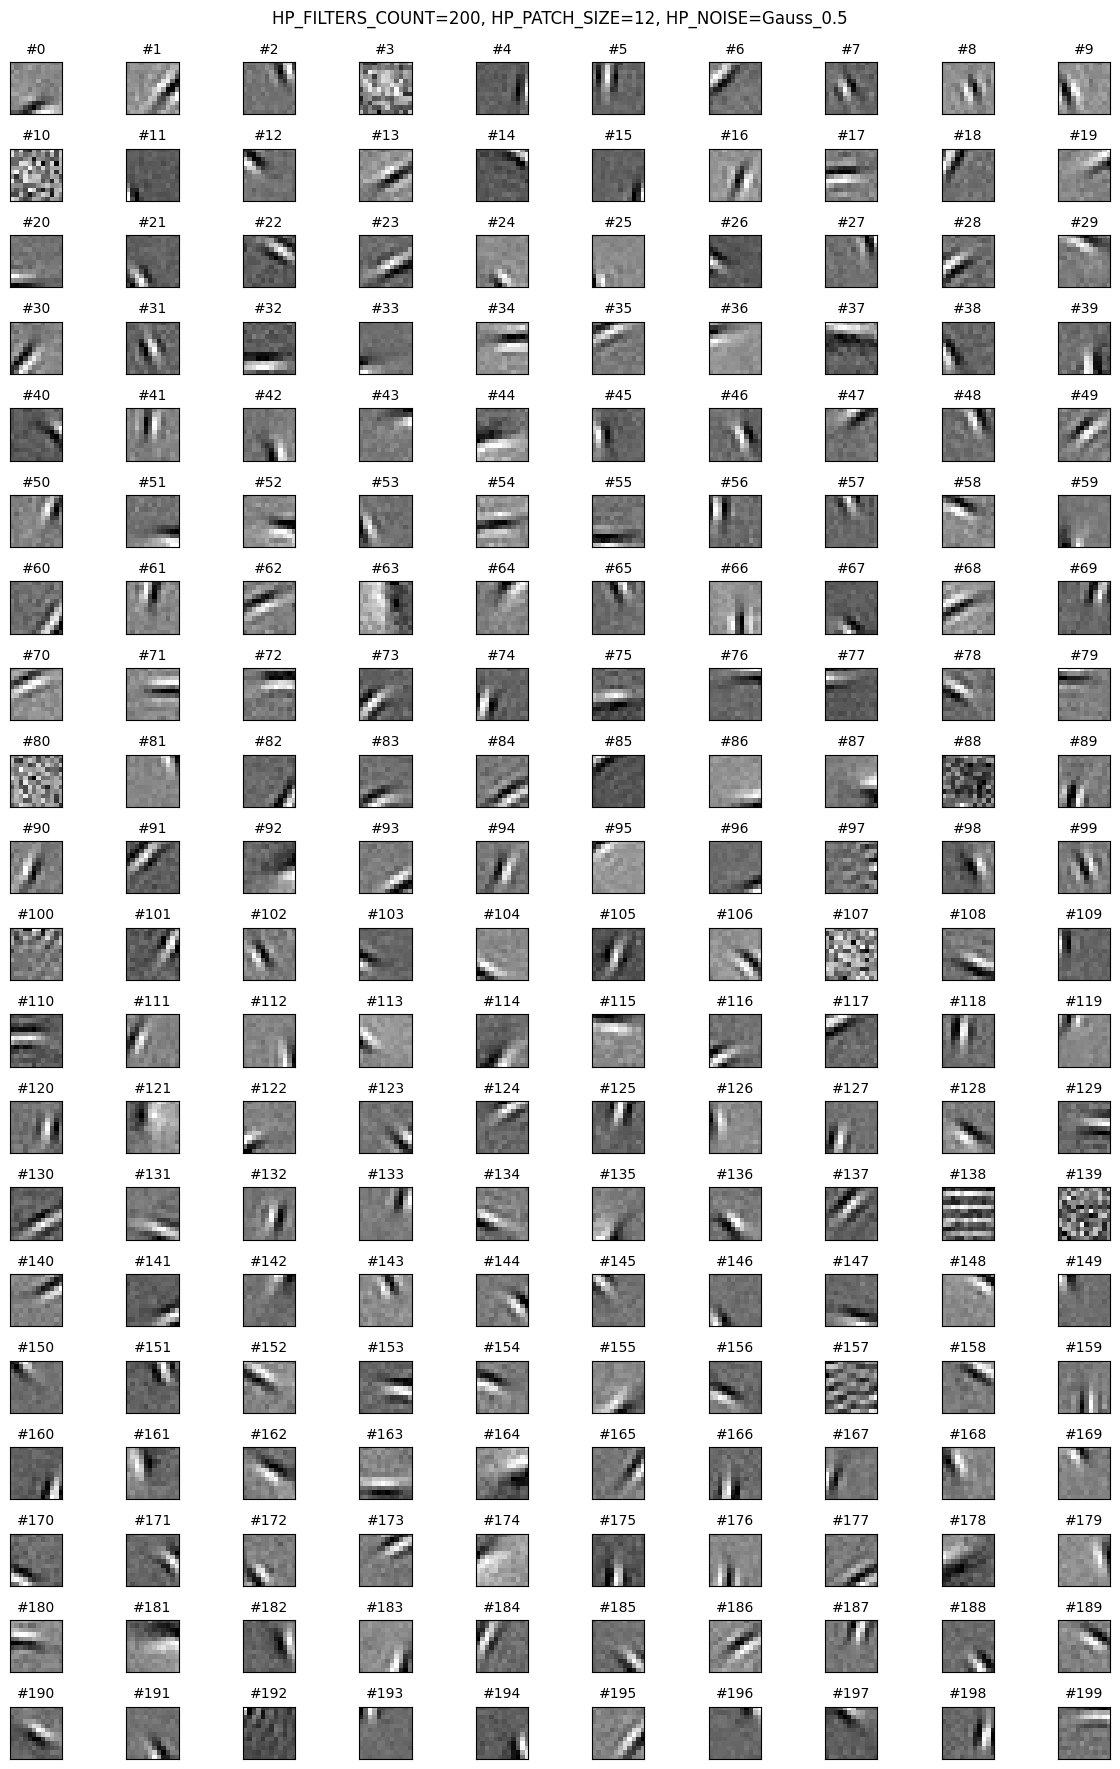